In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
from google.colab import files

uploaded = files.upload()


Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [4]:
import zipfile

with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", "r") as zip_ref:
    zip_ref.extractall("house_data")


In [5]:
import pandas as pd

train = pd.read_csv("house_data/train.csv")
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
import os

print(os.listdir())


['.config', 'house-prices-advanced-regression-techniques.zip', 'house_data', 'sample_data']


In [7]:
import os

os.listdir("house_data")


['train.csv', 'data_description.txt', 'sample_submission.csv', 'test.csv']

In [8]:
import pandas as pd

train = pd.read_csv("house_data/train.csv")

train.head()



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
train.shape


(1460, 81)

In [10]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [12]:
X = train.drop("SalePrice", axis=1)

y = train["SalePrice"]


In [13]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns :", len(numerical_cols))
print("Categorical Columns :", len(categorical_cols))

Numerical Columns : 37
Categorical Columns : 43


In [14]:
X[numerical_cols] = X[numerical_cols].fillna(
    X[numerical_cols].median()
)

In [15]:
X[categorical_cols] = X[categorical_cols].fillna("Missing")

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
X.shape

(1460, 261)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [20]:
y_pred = model.predict(X_test)

y_pred[:10]


array([160280.58929066, 343257.74396178,  89964.55692913, 176551.4748794 ,
       321041.78036166,  67931.17681763, 239480.62338335, 146644.89425977,
        62691.30962887, 151553.99908401])

In [21]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
892,154500,160280.589291
1105,325000,343257.743962
413,115000,89964.556929
522,159000,176551.474879
1036,315500,321041.780362
614,75500,67931.176818
218,311500,239480.623383
1160,146000,146644.894260
649,84500,62691.309629
887,135500,151553.999084


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)


MAE  : 23925.507783851877
MSE  : 6887923232.0190325
RMSE : 82993.5131924118
R² Score : 0.10200387233009434


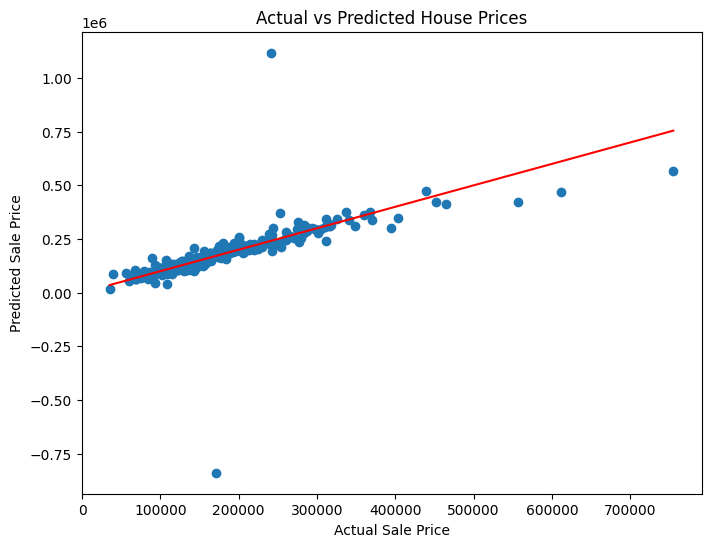

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.head()

,Feature,Coefficient
0,Id,0.252988
1,MSSubClass,15.947823
2,LotFrontage,18.048241
3,LotArea,0.738316
4,OverallQual,6778.070645


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 23925.507783851877
MSE : 6887923232.0190325
RMSE: 82993.5131924118
R² Score: 0.10200387233009434
